In [1]:
import torch
!pip install torch_geometric
from torch_geometric.data import Data

edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 1]], dtype=torch.long)
x = torch.tensor([[-1], [0], [1]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index)


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Rohin's Laptop\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
print(data)
print(data.validate(raise_on_error=True))
print(data.keys())
print(data['x'])

Data(x=[3, 1], edge_index=[2, 4])
True
['edge_index', 'x']
tensor([[-1.],
        [ 0.],
        [ 1.]])


In [3]:
for key,item in data:
  print(f'{key} found in data')
print('edge_attr' in data)
print(data.num_edges)
print(data.num_nodes)
print(data.num_node_features)
print(data.has_isolated_nodes())
print(data.has_self_loops())
print(data.is_directed())


x found in data
edge_index found in data
False
4
3
1
False
False
False


In [4]:
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root='/tmp/ENZYMES', name='ENZYMES')
print(len(dataset))
print(dataset.num_classes)
print(dataset.num_node_features)



Processing...


600
6
3


Done!


In [5]:
data = dataset[0]
print(data.is_undirected())
print(data.num_edges)
print(data.num_nodes)
print(data.num_node_features)
print(data.has_isolated_nodes())
print(data.has_self_loops())
print(data.is_directed())
data


True
168
37
3
False
False
False


Data(edge_index=[2, 168], x=[37, 3], y=[1])

In [6]:
dataset = dataset.shuffle()
train_dataset = dataset[:540]
test_dataset = dataset[540:]

In [7]:
from torch_geometric.utils import scatter
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader

dataset = TUDataset(root='/tmp/ENZYMES', name='ENZYMES', use_node_attr=True)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

for batch in loader:
    print(batch)
    print(batch.num_graphs)


print("\n")

for data in loader:
    x = scatter(data.x, data.batch, dim=0, reduce='mean')
    print(x.size())


DataBatch(edge_index=[2, 4308], x=[1143, 21], y=[32], batch=[1143], ptr=[33])
32
DataBatch(edge_index=[2, 3878], x=[1014, 21], y=[32], batch=[1014], ptr=[33])
32
DataBatch(edge_index=[2, 3740], x=[969, 21], y=[32], batch=[969], ptr=[33])
32
DataBatch(edge_index=[2, 4226], x=[1180, 21], y=[32], batch=[1180], ptr=[33])
32
DataBatch(edge_index=[2, 3924], x=[1012, 21], y=[32], batch=[1012], ptr=[33])
32
DataBatch(edge_index=[2, 4132], x=[1069, 21], y=[32], batch=[1069], ptr=[33])
32
DataBatch(edge_index=[2, 3834], x=[977, 21], y=[32], batch=[977], ptr=[33])
32
DataBatch(edge_index=[2, 4274], x=[1104, 21], y=[32], batch=[1104], ptr=[33])
32
DataBatch(edge_index=[2, 4126], x=[1055, 21], y=[32], batch=[1055], ptr=[33])
32
DataBatch(edge_index=[2, 4476], x=[1215, 21], y=[32], batch=[1215], ptr=[33])
32
DataBatch(edge_index=[2, 3738], x=[977, 21], y=[32], batch=[977], ptr=[33])
32
DataBatch(edge_index=[2, 3936], x=[1101, 21], y=[32], batch=[1101], ptr=[33])
32
DataBatch(edge_index=[2, 3984], x=

In [8]:
from torch_geometric.datasets import Planetoid
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

dataset = Planetoid(root='/tmp/Cora', name='Cora')

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_node_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

Processing...
Done!


Epoch 1, Loss: 1.946230411529541
Epoch 2, Loss: 1.8356471061706543
Epoch 3, Loss: 1.726162314414978
Epoch 4, Loss: 1.5795905590057373
Epoch 5, Loss: 1.430708408355713
Epoch 6, Loss: 1.2864187955856323
Epoch 7, Loss: 1.1090706586837769
Epoch 8, Loss: 0.9971855282783508
Epoch 9, Loss: 0.8971893787384033
Epoch 10, Loss: 0.8168351054191589
Epoch 11, Loss: 0.6560240387916565
Epoch 12, Loss: 0.6225822567939758
Epoch 13, Loss: 0.5479357838630676
Epoch 14, Loss: 0.4682624340057373
Epoch 15, Loss: 0.38641682267189026
Epoch 16, Loss: 0.39851149916648865
Epoch 17, Loss: 0.29404228925704956
Epoch 18, Loss: 0.30378952622413635
Epoch 19, Loss: 0.26110389828681946
Epoch 20, Loss: 0.22479939460754395
Epoch 21, Loss: 0.22005847096443176
Epoch 22, Loss: 0.1788284033536911
Epoch 23, Loss: 0.16925586760044098
Epoch 24, Loss: 0.15649494528770447
Epoch 25, Loss: 0.12576161324977875
Epoch 26, Loss: 0.11092788726091385
Epoch 27, Loss: 0.12493455410003662
Epoch 28, Loss: 0.10900231450796127
Epoch 29, Loss: 0.0

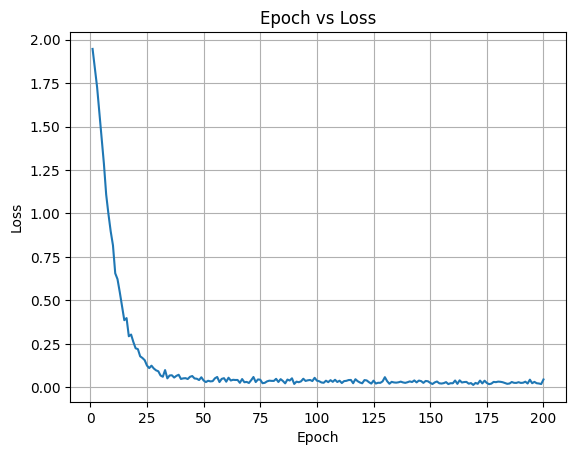

In [9]:
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN().to(device)
data = dataset[0].to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

model.train()
losses=[]
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f'Epoch {epoch+1}, Loss: {loss.item()}')

plt.plot(range(1, 201), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.grid(True)
plt.show()



In [ ]:
model.eval()
pred = model(data).argmax(dim=1)
correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())
print(f'Accuracy: {acc:.4f}')

In [ ]:
from torch_geometric.datasets import GeometricShapes
import torch_geometric.transforms as T

dataset = GeometricShapes(root='data/GeometricShapes')
print(dataset)
data = dataset[0]
print(data)
dataset.transform = T.SamplePoints(num=256)
data = dataset[0]
print(data)

In [14]:
!pip install torch-cluster
from torch_geometric.transforms import SamplePoints, KNNGraph

dataset.transform = T.Compose([SamplePoints(num=256), KNNGraph(k=6)])
data = dataset[0]
print(data)

^C


NameError: name 'T' is not defined

In [ ]:
from torch import Tensor
from torch.nn import Sequential, Linear, ReLU

from torch_geometric.nn import MessagePassing


class PointNetLayer(MessagePassing):
    def __init__(self, in_channels: int, out_channels: int):
        # Message passing with "max" aggregation.
        super().__init__(aggr='max')

        # Initialization of the MLP:
        # Here, the number of input features correspond to the hidden
        # node dimensionality plus point dimensionality (=3).
        self.mlp = Sequential(
            Linear(in_channels + 3, out_channels),
            ReLU(),
            Linear(out_channels, out_channels),
        )

    def forward(self,
        h: Tensor,
        pos: Tensor,
        edge_index: Tensor,
    ) -> Tensor:
        # Start propagating messages.
        return self.propagate(edge_index, h=h, pos=pos)

    def message(self,
        h_j: Tensor,
        pos_j: Tensor,
        pos_i: Tensor,
    ) -> Tensor:
        # h_j: The features of neighbors as shape [num_edges, in_channels]
        # pos_j: The position of neighbors as shape [num_edges, 3]
        # pos_i: The central node position as shape [num_edges, 3]

        edge_feat = torch.cat([h_j, pos_j - pos_i], dim=-1)
        return self.mlp(edge_feat)

In [ ]:
from torch_geometric.nn import global_max_pool


class PointNet(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = PointNetLayer(3, 32)
        self.conv2 = PointNetLayer(32, 32)
        self.classifier = Linear(32, dataset.num_classes)

    def forward(self,
        pos: Tensor,
        edge_index: Tensor,
        batch: Tensor,
    ) -> Tensor:

        # Perform two-layers of message passing:
        h = self.conv1(h=pos, pos=pos, edge_index=edge_index)
        h = h.relu()
        h = self.conv2(h=h, pos=pos, edge_index=edge_index)
        h = h.relu()

        # Global Pooling:
        h = global_max_pool(h, batch)  # [num_examples, hidden_channels]

        # Classifier:
        return self.classifier(h)


model = PointNet()
print(model)

In [ ]:
from torch_geometric.loader import DataLoader

train_dataset = GeometricShapes(root='data/GeometricShapes', train=True)
train_dataset.transform = T.Compose([SamplePoints(num=256), KNNGraph(k=6)])
test_dataset = GeometricShapes(root='data/GeometricShapes', train=False)
test_dataset.transform = T.Compose([SamplePoints(num=256), KNNGraph(k=6)])

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10)

model = PointNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()

    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        logits = model(data.pos, data.edge_index, data.batch)
        loss = criterion(logits, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs

    return total_loss / len(train_loader.dataset)


@torch.no_grad()
def test():
    model.eval()

    total_correct = 0
    for data in test_loader:
        logits = model(data.pos, data.edge_index, data.batch)
        pred = logits.argmax(dim=-1)
        total_correct += int((pred == data.y).sum())

    return total_correct / len(test_loader.dataset)

for epoch in range(1, 51):
    loss = train()
    test_acc = test()
    print(f'Epoch: {epoch:02d}, Loss: {loss:.4f}, Test Acc: {test_acc:.4f}')